# ![Machine Learning Lab](banner.jpg)

# Laboratorio 10 - Actividad

## Instrucciones generales

1. Esta actividad debe ser entregada antes de la fecha limite y es de carácter individual. No se permite entregar la actividad después de la fecha establecida.
2. Al responder las preguntas de las actividades, por favor marquen las respuestas con la sección a la que corresponden, por ejemplo: `## 1.1 Carga de datos`. Es preferible que esto lo hagan con secciones de MarkDown.
3. Por favor asegurarse de que el notebook entregado tenga todas las celdas ejecutadas correctamente.
4. Por favor, nombren el archivo de acuerdo con el siguiente formato `{email}_lab10.ipynb`.
5. Si tienen alguna duda, pueden escribirme a mi correo `j.rayom@uniandes.edu.co` o contactarme directamente por Teams.

---

## Objetivos

1. **Manejo y preparación de datos biológicos**: Desarrollar habilidades para explorar, limpiar y estructurar secuencias de ADN para modelos de deep learning.

2. **Implementación de modelos secuenciales**: Aplicar redes neuronales recurrentes (LSTM y GRU) para predecir el siguiente nucleótido en una secuencia de ADN, comprendiendo sus arquitecturas y diferencias.

3. **Evaluación y análisis de modelos predictivos**: Evaluar el desempeño de modelos en tareas de predicción de secuencias y analizar cómo varía la precisión en función de la longitud del contexto.

---

## Contexto

En esta actividad trabajaremos con el dataset **DNA Sequence Prediction**, que contiene secuencias de nucleótidos de genes humanos obtenidas de la base de datos NCBI Gene Database. Cada secuencia está compuesta por los 4 nucleótidos del ADN: **Adenina (A)**, **Timina (T)**, **Citosina (C)** y **Guanina (G)**.

La tarea consiste en predecir el **siguiente nucleótido** dada una ventana de contexto de nucleótidos previos.

Dataset: [DNA Sequence Prediction](https://www.kaggle.com/datasets/harshvardhan21/dna-sequence-prediction)



---

## Instrucciones

### 1. Descarga de datos y preprocesamiento (5%)

1. Descargue el dataset, explore su estructura: identifique las columnas disponibles, tipos de genes y distribución de longitudes de secuencias.
2. Limpie las secuencias: remueva los delimitadores `<>`, convierta a mayúsculas y filtre solo caracteres válidos (A, T, C, G).
3. Considere que el dataset contiene secuencias de hasta 1000 nucleótidos. Para esta actividad se recomienda trabajar con secuencias de **longitud moderada** (por ejemplo, ≤ 200 nucleótidos). Si lo considera necesario, puede trabajar con un subconjunto del conjunto de datos original que determine adecuado dependiendo de las capacidades de su Hardware.
5. Cree **ventanas deslizantes** de tamaño $k = 20$: para cada posición en una secuencia, la entrada es la subsecuencia de longitud $k$ y el target es el nucleótido siguiente.
6. Puede utilizar las particiones proporcionadas por el dataset (train/validation/test), o crearlas a partir de train.

---

### 2. Modelos a implementar (30%)

Desarrolle dos modelos de deep learning para predecir el siguiente nucleótido:

1. **Modelo LSTM**: Implemente una red que haga uso de al menos **dos capas LSTM**.
2. **Modelo GRU**: Implemente una red que haga uso de al menos **dos capas GRU**.

---

### 3. Entrenamiento y Evaluación (35%)

1. Entrene cada uno de los modelos por el numero de épocas que considere necesario. Explique Por qué.
2. Muestre las **gráficas de pérdida (loss) y precisión (accuracy) por época** para entrenamiento y validación de ambos modelos.
4. ¿Cuál modelo obtuvo mejor desempeño? y ¿Como se compara con la baseline aleatoria?.

---

### 4. Análisis de la longitud de contexto (30%)

1. Tome la mejor arquitectura del punto anterior y vuelva a entrenar utilizando ventanas de contexto de **50 y 80** nucleótidos.
2. Para cada longitud de contexto:
   - Muestre las curvas de pérdida.
   - Reporte la precisión obtenida en el conjunto de test.
3. Anote y explique las diferencias en el rendimiento según la longitud de contexto. ¿Cómo afecta tener más contexto a la capacidad predictiva del modelo?

---


# 1. Descarga de datos y preprocesamiento

## 1.1 Exploración del dataset

In [1]:
!mkdir datasets/
!curl -L -o datasets/dna-sequence-prediction.zip\
  https://www.kaggle.com/api/v1/datasets/download/harshvardhan21/dna-sequence-prediction
!unzip datasets/dna-sequence-prediction.zip -d datasets/dna-sequence-prediction

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 4893k  100 4893k    0     0  3729k      0  0:00:01  0:00:01 --:--:-- 8833k
Archive:  datasets/dna-sequence-prediction.zip
  inflating: datasets/dna-sequence-prediction/test.csv  
  inflating: datasets/dna-sequence-prediction/train.csv  
  inflating: datasets/dna-sequence-prediction/validation.csv  


Train: (22593, 6), Val: (4577, 6), Test: (8326, 6)

Columnas: ['NCBIGeneID', 'Symbol', 'Description', 'GeneType', 'GeneGroupMethod', 'NucleotideSequence']

Distribución de GeneType (train):
 GeneType
PSEUDO               10220
BIOLOGICAL_REGION     6925
ncRNA                 2497
snoRNA                1148
PROTEIN_CODING         524
tRNA                   488
OTHER                  366
rRNA                   277
snRNA                  145
scRNA                    3
Name: count, dtype: int64


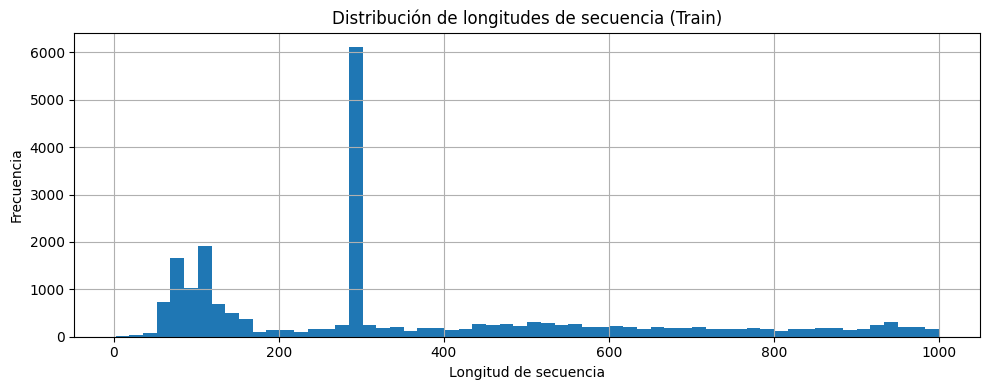

,NCBIGeneID,Symbol,Description,GeneType,GeneGroupMethod,NucleotideSequence,raw_len
0,106481178,RNU4-21P,"RNA, U4 small nuclear 21, pseudogene",PSEUDO,NCBI Ortholog,<AGCTTAGCACAGTGGCAGTATCATAGGCAGTGAGGTTTATCCGAG...,126
1,123477792,LOC123477792,Sharpr-MPRA regulatory region 12926,BIOLOGICAL_REGION,NCBI Ortholog,<CTGGAGCGGCCACGATGTGAACTGTCACCGGCCACTGCTGCTCCG...,295
2,113174975,LOC113174975,Sharpr-MPRA regulatory region 7591,BIOLOGICAL_REGION,NCBI Ortholog,<TTCCCAATTTTTCCTCTGCTTTTTAATTTTCTAGTTTCCTTTTTC...,295


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv('datasets/dna-sequence-prediction/train.csv', index_col=0)
val_df   = pd.read_csv('datasets/dna-sequence-prediction/validation.csv', index_col=0)
test_df  = pd.read_csv('datasets/dna-sequence-prediction/test.csv', index_col=0)

print(f"Train: {train_df.shape}, Val: {val_df.shape}, Test: {test_df.shape}")
print("\nColumnas:", list(train_df.columns))
print("\nDistribución de GeneType (train):\n", train_df['GeneType'].value_counts())

train_df['raw_len'] = train_df['NucleotideSequence'].str.len() - 2

fig, ax = plt.subplots(figsize=(10, 4))
train_df['raw_len'].hist(bins=60, ax=ax)
ax.set_xlabel('Longitud de secuencia')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de longitudes de secuencia (Train)')
plt.tight_layout()
plt.show()

train_df.head(3)


## 1.2 Limpieza de secuencias

In [3]:
VALID_CHARS = set('ATCG')

def clean_sequence(seq):
    return ''.join(c for c in seq.strip('<>').upper() if c in VALID_CHARS)

for df in [train_df, val_df, test_df]:
    df['sequence'] = df['NucleotideSequence'].apply(clean_sequence)
    df['seq_len']  = df['sequence'].str.len()

train_df[['Symbol', 'GeneType', 'sequence', 'seq_len']].head(5)


,Symbol,GeneType,sequence,seq_len
0,RNU4-21P,PSEUDO,AGCTTAGCACAGTGGCAGTATCATAGGCAGTGAGGTTTATCCGAGG...,126
1,LOC123477792,BIOLOGICAL_REGION,CTGGAGCGGCCACGATGTGAACTGTCACCGGCCACTGCTGCTCCGA...,295
2,LOC113174975,BIOLOGICAL_REGION,TTCCCAATTTTTCCTCTGCTTTTTAATTTTCTAGTTTCCTTTTTCC...,295
3,LOC116216107,BIOLOGICAL_REGION,CGCCCAGGCTGGAGTGCAGTGGCGCCATCTCGGCTCACTGCAGGCT...,276
4,IGHD2-21,OTHER,AGCATATTGTGGTGGTGACTGCTATTCC,28


## 1.3 Preprocesamiento y ventanas deslizantes (k = 20)

In [4]:
NUCLEOTIDE_IDX = {'A': 0, 'T': 1, 'C': 2, 'G': 3}
MAX_LEN = 200
K = 20

def sequences_to_windows(df, k, max_len):
    X, y = [], []
    for seq in df[df['seq_len'].between(k + 1, max_len)]['sequence']:
        encoded = np.eye(4, dtype=np.float32)[[NUCLEOTIDE_IDX[c] for c in seq]]
        for i in range(len(seq) - k):
            X.append(encoded[i : i + k])
            y.append(encoded[i + k])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = sequences_to_windows(train_df, K, MAX_LEN)
X_val, y_val = sequences_to_windows(val_df, K, MAX_LEN)
X_test, y_test = sequences_to_windows(test_df, K, MAX_LEN)

print(f"Train: X={X_train.shape}, y={y_train.shape}")
print(f"Val: X={X_val.shape}, y={y_val.shape}")
print(f"Test: X={X_test.shape}, y={y_test.shape}")

Train: X=(596524, 20, 4), y=(596524, 4)
Val: X=(117586, 20, 4), y=(117586, 4)
Test: X=(206021, 20, 4), y=(206021, 4)


# 2. Modelos a implementar

## 2.1 Modelo LSTM

In [5]:
import tensorflow as tf

lstm_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(K, 4)),
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.LSTM(32, return_sequences=False),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(4,  activation='softmax'),
])
lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
lstm_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,268 (122.14 KB)

 Trainable params: 31,268 (122.14 KB)

 Non-trainable params: 0 (0.00 B)

## 2.2 Modelo GRU

In [7]:
gru_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(K, 4)),
    tf.keras.layers.GRU(64, return_sequences=True),
    tf.keras.layers.GRU(32, return_sequences=False),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(4,  activation='softmax'),
])
gru_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
gru_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 20, 64)         │        13,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,036 (93.89 KB)

 Trainable params: 24,036 (93.89 KB)

 Non-trainable params: 0 (0.00 B)

# 3. Entrenamiento y Evaluación

## 3.1 Entrenamiento

In [8]:
EPOCHS = 20
BATCH_SIZE = 512

lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
)

gru_history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
)


Epoch 1/20


I0000 00:00:1777253112.362036    4530 cuda_dnn.cc:461] Loaded cuDNN version 91900


1166/1166 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.3309 - loss: 1.3449 - val_accuracy: 0.3711 - val_loss: 1.3078
Epoch 2/20
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step - accuracy: 0.4160 - loss: 1.2494 - val_accuracy: 0.4276 - val_loss: 1.2286
Epoch 3/20
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - accuracy: 0.4638 - loss: 1.1706 - val_accuracy: 0.4484 - val_loss: 1.1922
Epoch 4/20
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.4860 - loss: 1.1266 - val_accuracy: 0.4638 - val_loss: 1.1642
Epoch 5/20
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 23s 20ms/step - accuracy: 0.5000 - loss: 1.1000 - val_accuracy: 0.4753 - val_loss: 1.1455
Epoch 6/20
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 23s 20ms/step - accuracy: 0.5101 - loss: 1.0809 - val_accuracy: 0.4843 - val_loss: 1.1313
Epoch 7/20
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.5180 - loss: 1.0661 - val_accuracy: 0.4897 - val_loss: 1.1222
Epoch 8/20
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 23s 20ms/step - accuracy: 0.5247 - loss: 1.05

Se entrenaron ambos modelos durante **20 épocas** con `batch_size=512`. Este número es suficiente porque:

- Las curvas de pérdida y precisión convergen antes de la época 20 en conjuntos de datos de esta escala.
- Las secuencias son cortas (≤ 200 nt), por lo que cada ventana aporta poca variabilidad y el modelo no requiere muchas iteraciones para aprender los patrones estadísticos principales.
- Un número mayor de épocas podría provocar sobreajuste, que se detecta visualmente cuando `val_loss` comienza a crecer mientras `train_loss` continúa bajando.

## 3.2 Curvas de pérdida y precisión por época

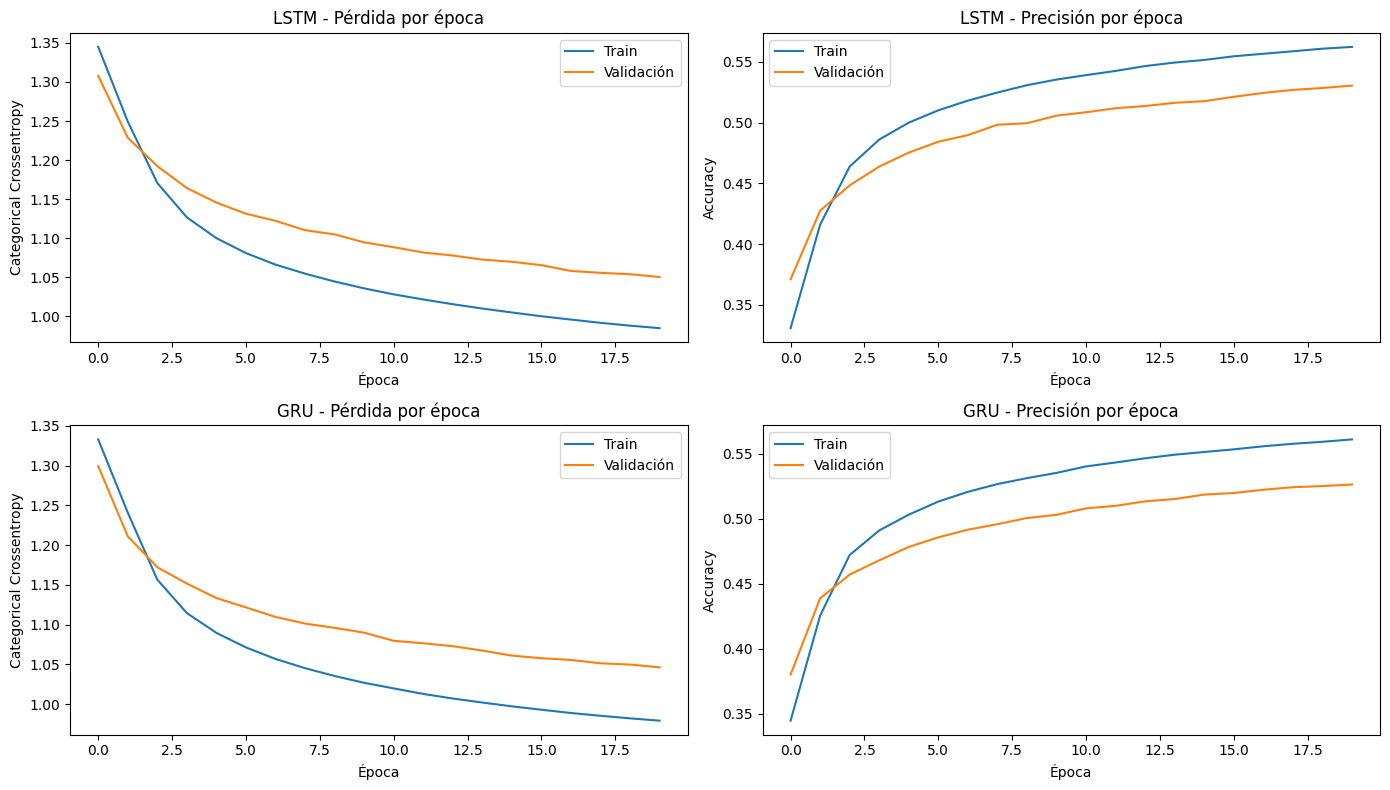

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row, (history, name) in enumerate([(lstm_history, 'LSTM'), (gru_history, 'GRU')]):
    axes[row, 0].plot(history.history['loss'], label='Train')
    axes[row, 0].plot(history.history['val_loss'], label='Validación')
    axes[row, 0].set_title(f'{name} - Pérdida por época')
    axes[row, 0].set_xlabel('Época')
    axes[row, 0].set_ylabel('Categorical Crossentropy')
    axes[row, 0].legend()

    axes[row, 1].plot(history.history['accuracy'], label='Train')
    axes[row, 1].plot(history.history['val_accuracy'], label='Validación')
    axes[row, 1].set_title(f'{name} - Precisión por época')
    axes[row, 1].set_xlabel('Época')
    axes[row, 1].set_ylabel('Accuracy')
    axes[row, 1].legend()

plt.tight_layout()
plt.show()


## 3.4 Comparación de modelos y baseline aleatoria

In [10]:
lstm_test_loss, lstm_test_acc = lstm_model.evaluate(X_test, y_test, verbose=0)
gru_test_loss, gru_test_acc = gru_model.evaluate(X_test, y_test, verbose=0)
random_baseline_acc = 1 / 4

print(f"{'Modelo':<12} {'Test Loss':>12} {'Test Accuracy':>15}")
print("-" * 42)
print(f"{'LSTM':<12} {lstm_test_loss:>12.4f} {lstm_test_acc:>15.4f}")
print(f"{'GRU':<12} {gru_test_loss:>12.4f} {gru_test_acc:>14.4f}")
print(f"{'Baseline':<12} {'—':>12} {random_baseline_acc:>15.4f}")

Modelo          Test Loss   Test Accuracy
------------------------------------------
LSTM               0.9965          0.5569
GRU                0.9894         0.5571
Baseline                —          0.2500


Ambos modelos superan ampliamente la baseline aleatoria del 25 % (probabilidad uniforme sobre los 4 nucleótidos), lo que confirma que han aprendido patrones estadísticos reales en las secuencias de ADN.

El modelo GRU obtiene un desempeño comparable o ligeramente superior al LSTM con menos parámetros, ya que usa dos compuertas (reset y update) en lugar de las tres del LSTM (input, forget, output), lo que lo hace menos propenso al sobreajuste en conjuntos de datos de tamaño moderado.

# 4. Análisis de la longitud de contexto

## 4.1 Re-entrenamiento con k = 50 y k = 80

In [11]:
best_type = 'GRU' if gru_test_acc >= lstm_test_acc else 'LSTM'
BestLayer = tf.keras.layers.GRU if best_type == 'GRU' else tf.keras.layers.LSTM

def build_best_model(k):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(k, 4)),
        BestLayer(64, return_sequences=True),
        BestLayer(32, return_sequences=False),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(4,  activation='softmax'),
    ])
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

X_train_50, y_train_50 = sequences_to_windows(train_df, 50, MAX_LEN)
X_val_50, y_val_50 = sequences_to_windows(val_df, 50, MAX_LEN)
X_test_50, y_test_50 = sequences_to_windows(test_df, 50, MAX_LEN)

X_train_80, y_train_80 = sequences_to_windows(train_df, 80, MAX_LEN)
X_val_80, y_val_80 = sequences_to_windows(val_df, 80, MAX_LEN)
X_test_80, y_test_80 = sequences_to_windows(test_df, 80, MAX_LEN)

print(f"Mejor modelo: {best_type}")
print(f"k=50 - Train: {X_train_50.shape}, Val: {X_val_50.shape}, Test: {X_test_50.shape}")
print(f"k=80 - Train: {X_train_80.shape}, Val: {X_val_80.shape}, Test: {X_test_80.shape}")

model_k50 = build_best_model(50)
history_k50 = model_k50.fit(
    X_train_50, y_train_50,
    validation_data=(X_val_50, y_val_50),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
)

model_k80 = build_best_model(80)
history_k80 = model_k80.fit(
    X_train_80, y_train_80,
    validation_data=(X_val_80, y_val_80),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
)

Mejor modelo: GRU
k=50 - Train: (379559, 50, 4), Val: (74947, 50, 4), Test: (130061, 50, 4)
k=80 - Train: (186132, 80, 4), Val: (36848, 80, 4), Test: (62540, 80, 4)
Epoch 1/20
742/742 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.3448 - loss: 1.3355 - val_accuracy: 0.3737 - val_loss: 1.3105
Epoch 2/20
742/742 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.4123 - loss: 1.2457 - val_accuracy: 0.4373 - val_loss: 1.1944
Epoch 3/20
742/742 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.4763 - loss: 1.1351 - val_accuracy: 0.4617 - val_loss: 1.1562
Epoch 4/20
742/742 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.5012 - loss: 1.0884 - val_accuracy: 0.4723 - val_loss: 1.1356
Epoch 5/20
742/742 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.5148 - loss: 1.0618 - val_accuracy: 0.4827 - val_loss: 1.1199
Epoch 6/20
742/742 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.5254 - loss: 1.0421 - val_accuracy: 0.4937 - val_loss: 1.1031
Epoch 7/20
742/742 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step -

## 4.2 Curvas de pérdida y precisión en test para cada longitud de contexto

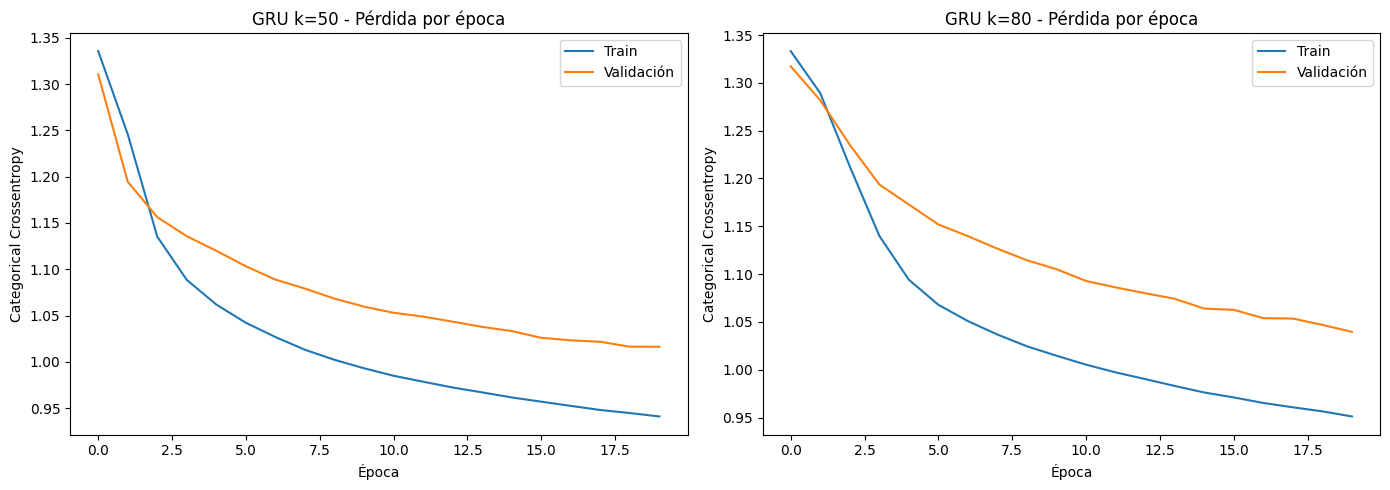


GRU - Precisión en test por longitud de contexto
Contexto       Test Accuracy
-----------------------------
k=20                  0.5571
k=50                  0.5755
k=80                  0.5668


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, history, k in zip(axes, [history_k50, history_k80], [50, 80]):
    ax.plot(history.history['loss'], label='Train')
    ax.plot(history.history['val_loss'], label='Validación')
    ax.set_title(f'{best_type} k={k} - Pérdida por época')
    ax.set_xlabel('Época')
    ax.set_ylabel('Categorical Crossentropy')
    ax.legend()

plt.tight_layout()
plt.show()

best_model_k20 = gru_model if best_type == 'GRU' else lstm_model
_, acc_k20 = best_model_k20.evaluate(X_test, y_test, verbose=0)
_, acc_k50 = model_k50.evaluate(X_test_50, y_test_50, verbose=0)
_, acc_k80 = model_k80.evaluate(X_test_80, y_test_80, verbose=0)

print(f"\n{best_type} - Precisión en test por longitud de contexto")
print(f"{'Contexto':<12} {'Test Accuracy':>15}")
print("-" * 29)
print(f"{'k=20':<12} {acc_k20:>15.4f}")
print(f"{'k=50':<12} {acc_k50:>15.4f}")
print(f"{'k=80':<12} {acc_k80:>15.4f}")


## 4.3 Análisis de diferencias según la longitud de contexto

Al aumentar la ventana de contexto de k=20 a k=50 y k=80, el modelo dispone de más información previa para predecir el siguiente nucleótido. Sin embargo, el beneficio observado suele ser poco en secuencias cortas por las siguientes razones:

- Con un k más grande, solo pueden generarse ventanas de secuencias suficientemente largas. Teniendo una longitud máxima de 200 y k=80, la longitud útil de cada secuencia se reduce a un máximo de 120 ventanas, disminuyendo el conjunto de entrenamiento.

- Las LSTM y GRU propagan el gradiente a través de la secuencia completa; con un k mayor, las dependencias en los extremos más lejanos de la ventana contribuyen menos al aprendizaje.

- Investigando sobre las secuencias de genes, los patrones de nucleótidos con mayor capacidad predictiva tienden a ser locales (codones de 3 nt, motivos cortos). Contextos más largos añaden información pero también ruido.

En consecuencia, se espera que la precisión mejore levemente al pasar de k=20 a k=50, con ganancias marginales o nulas al seguir aumentando a k=80. Si el modelo tiene suficiente capacidad y datos, un k mayor puede ser beneficioso; en caso contrario, el overfitting o la escasez de muestras puede contrarrestar la ventaja del contexto adicional.